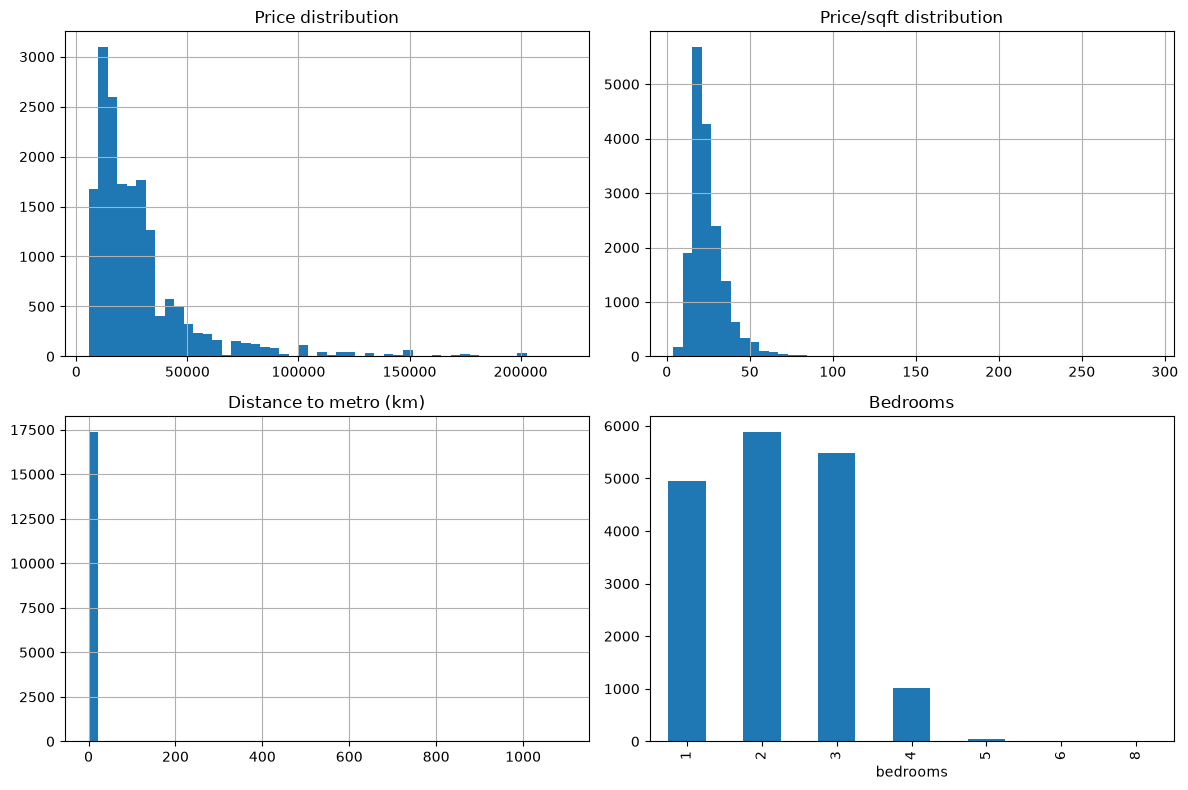

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('../db/rentals.db')
df = pd.read_sql_query("""
    SELECT li.*, l.locality_name, l.locality_group, l.is_sparse
    FROM listings li
    JOIN localities l ON li.locality_id = l.locality_id
""", conn)

df['price_per_sqft'] = df['price'] / df['size_sq_ft']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
df['price'].hist(bins=50, ax=axes[0,0]); axes[0,0].set_title('Price distribution')
df['price_per_sqft'].hist(bins=50, ax=axes[0,1]); axes[0,1].set_title('Price/sqft distribution')
df['closest_metro_km'].hist(bins=50, ax=axes[1,0]); axes[1,0].set_title('Distance to metro (km)')
df['bedrooms'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1]); axes[1,1].set_title('Bedrooms')
plt.tight_layout()
plt.savefig('../docs/eda_distributions.png')
plt.show()

In [2]:
corr_cols = ['price', 'price_per_sqft', 'size_sq_ft', 'bedrooms',
             'closest_metro_km', 'airport_dist_km', 'aiims_dist_km', 'ndrlw_dist_km']
print(df[corr_cols].corr()['price'].sort_values())

aiims_dist_km      -0.111478
airport_dist_km    -0.024311
ndrlw_dist_km      -0.016675
closest_metro_km    0.012840
price_per_sqft      0.536719
bedrooms            0.584434
size_sq_ft          0.760074
price               1.000000
Name: price, dtype: float64


                       mean     median  count
locality_group                               
Delhi West        39.441253  38.856209    260
Delhi North       31.189662  27.500000    161
Delhi South       29.805374  27.777778   3609
South West Delhi  27.690935  26.595745     67
Delhi Central     26.614948  25.555556   2643
North Delhi       26.236616  24.545455   1215
North West Delhi  25.341132  25.346557      6
Rohini            24.604642  22.222222    261
Other             24.346139  22.065574   1994
West Delhi        21.684006  20.661157   2159
Delhi East        21.261082  20.000000   1829
Dwarka            18.687811  17.670420   2360


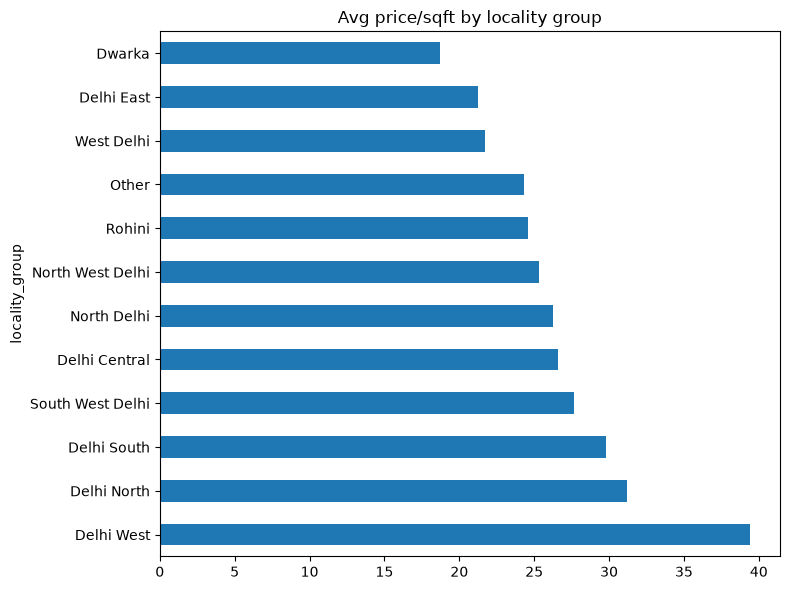

In [3]:
group_stats = df[df['is_sparse']==0].groupby('locality_group')['price_per_sqft'].agg(['mean','median','count']).sort_values('mean', ascending=False)
print(group_stats)

group_stats['mean'].plot(kind='barh', figsize=(8,6), title='Avg price/sqft by locality group')
plt.tight_layout()
plt.savefig('../docs/locality_price_comparison.png')
plt.show()

In [4]:
pivot = df.pivot_table(values='price_per_sqft', index='bedrooms', columns='property_type', aggfunc='median')
print(pivot)

property_type  Apartment  Independent Floor  Independent House      Villa
bedrooms                                                                 
1              23.333333          22.500000          22.967033  28.260870
2              20.563492          23.041475          21.333333  22.041115
3              18.333333          25.263158          23.684211  22.159091
4              17.391304          30.555556          20.000000  21.052632
5              22.068966          20.625000          41.666667  34.722222
6              22.400000          33.845029          34.305556        NaN
8                    NaN           4.000000                NaN        NaN


In [5]:
df[df['locality_group']=='Dwarka'][['size_sq_ft','bedrooms','property_type']].describe(include='all')

,size_sq_ft,bedrooms,property_type
count,2422.000000,2422.000000,2422
unique,NaN,NaN,4
top,NaN,NaN,Apartment
freq,NaN,NaN,2079
mean,1557.379438,2.751445,NaN
std,549.041847,0.814564,NaN
min,221.000000,1.000000,NaN
25%,1200.000000,2.000000,NaN
50%,1658.000000,3.000000,NaN
75%,1800.000000,3.000000,NaN


In [6]:
group_stats['is_group_sparse'] = group_stats['count'] < 30  # or whatever threshold you think defensible

In [7]:
df.groupby('locality_group').apply(lambda g: g['price'].corr(g['closest_metro_km']))

locality_group
Delhi Central       0.067729
Delhi East          0.162033
Delhi North        -0.224559
Delhi South        -0.263198
Delhi West          0.431040
Dwarka              0.005514
North Delhi        -0.065390
North West Delhi    0.783261
Other              -0.040659
Rohini             -0.206006
South West Delhi    0.345804
West Delhi          0.085399
dtype: float64

In [8]:
# Citywide property type / size profile (no locality filter)
df[['size_sq_ft','bedrooms','property_type']].describe(include='all')

,size_sq_ft,bedrooms,property_type
count,17388.000000,17388.000000,17388
unique,NaN,NaN,4
top,NaN,NaN,Independent Floor
freq,NaN,NaN,10932
mean,1139.019381,2.156487,NaN
std,677.617456,0.916331,NaN
min,210.000000,1.000000,NaN
25%,650.000000,1.000000,NaN
50%,900.000000,2.000000,NaN
75%,1600.000000,3.000000,NaN
